# Recommender Systems — Collaborative Filtering, Content-Based & Matrix Factorization

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/02-unsupervised-learning/recommender-systems/notes.ipynb)

*Picks up after [Market Basket Analysis](../market-basket-analysis/notes.ipynb). That notebook found item
pairs that sell together. This one gives every **user** their own personal list.*


## 1. What a recommender actually does

Market basket rules say "people who buy jeans also buy belts" — the same advice for everybody. A **recommender
system** is personal:

1. For one user and one item, **predict a score** — how much would this user like this item? (a rating, or the
   chance they'll click or buy)
2. Score *every* item the user hasn't tried yet.
3. **Rank** by score and show the top few.

Netflix's "Because you watched…", Amazon's "customers also bought", Spotify's Discover Weekly — all this.

Same Veloura store as before. Now we know *who* bought and rated what.


## 2. The user–item matrix

All the data fits in one table `A`: one row per user, one column per item, and the cell holds the **interaction**
— a rating, or the number of times they bought it. If the user never tried the item, the cell is empty.

Here is a small one — 4 users, 6 products, ratings 1–5:


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

nan = np.nan
items = ["jeans", "tee", "sneakers", "belt", "scarf", "cap"]
R = pd.DataFrame(
    [[5, 4, nan, nan, 1, 2],
     [5, 3, 4, nan, 1, 2],
     [1, 2, nan, 5, 4, 5],
     [4, 5, 5, 3, nan, 1]],
    index=["Asha", "Bala", "Chitra", "Dev"], columns=items,
)
R

,jeans,tee,sneakers,belt,scarf,cap
Asha,5,4,NaN,NaN,1.0,2
Bala,5,3,4.0,NaN,1.0,2
Chitra,1,2,NaN,5.0,4.0,5
Dev,4,5,5.0,3.0,NaN,1


Asha has not rated `sneakers` or `belt`. The whole job: **fill in those blanks**, then recommend whichever
blank scores higher.

**The matrix is mostly empty.** A real store has millions of users and thousands of products, and one user
touches maybe 100 of them. That's called a **sparse** matrix. Netflix-size: 1,000,000 users × 10,000 titles =
10 billion cells, with at most ~100 filled per row — over 99% blank.


## 3. Collaborative filtering — "people like you"

No product details needed. We only use **behaviour**: find people with similar taste, and borrow their opinions.

### 3a. User–user similarity

**Step 1 — how similar are two users?** Treat each user's ratings as a list of numbers (a vector) and measure the
angle between two lists with **cosine similarity**:

$$
\text{sim}(u, v) = \frac{u \cdot v}{\|u\| \, \|v\|}
$$

1 means same direction (same taste), 0 means unrelated. We compare only on items **both** users rated.


In [2]:
def cosine_sim(u, v):
    both = u.notna() & v.notna()
    a, b = u[both].to_numpy(), v[both].to_numpy()
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b))

target = "Asha"
sims = {o: cosine_sim(R.loc[target], R.loc[o]) for o in R.index if o != target}
pd.Series(sims, name=f"similarity to {target}").round(3)

Bala      0.992
Chitra    0.587
Dev       0.966
Name: similarity to Asha, dtype: float64

Bala is almost a copy of Asha (0.99). Chitra is the opposite type — loves belts, scarves and caps, dislikes
jeans — and scores far lower (0.59). (Dev also scores high because everyone here rates on the same 1–5 scale and
cosine on raw ratings is generous — a known weakness.)

**Step 2 — predict a missing rating.** Take the ratings of everyone who *did* rate that item, and average them,
**weighted by similarity**. More similar users count more:

$$
\hat{r}_{u,i} = \frac{\sum_v \text{sim}(u,v) \cdot r_{v,i}}{\sum_v \text{sim}(u,v)}
$$

By hand for Asha and `sneakers`. Only Bala (rated it 4) and Dev (rated it 5) have rated it, so Chitra is left out:


In [3]:
def predict_user_user(R, user, item):
    num = den = 0.0
    for other in R.index:
        if other == user or np.isnan(R.loc[other, item]):
            continue
        s = cosine_sim(R.loc[user], R.loc[other])
        num += s * R.loc[other, item]
        den += s
    return num / den

for item in ["sneakers", "belt"]:
    print(f"Predicted rating, Asha → {item}: {predict_user_user(R, 'Asha', item):.2f}")

Predicted rating, Asha → sneakers: 4.49
Predicted rating, Asha → belt: 3.76


Asha is predicted to like sneakers (4.49) more than belts (3.76), so **sneakers go first** in her list. The belt
score is lower because the belt ratings came from Chitra (unlike Asha) and Dev (a lukewarm 3).


### 3b. Item–item similarity

Flip the idea: instead of finding similar *users*, find similar *items* — items that the same people rate the
same way. To predict Asha → sneakers, look at items Asha *has* rated, and see how much each behaves like
sneakers.


In [4]:
def item_sim(R, i, j):
    both = R[i].notna() & R[j].notna()
    a, b = R.loc[both, i].to_numpy(), R.loc[both, j].to_numpy()
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b)) if both.sum() else np.nan

def predict_item_item(R, user, item):
    num = den = 0.0
    for other_item in R.columns:
        if other_item == item or np.isnan(R.loc[user, other_item]):
            continue
        s = item_sim(R, item, other_item)
        if np.isnan(s):
            continue
        num += s * R.loc[user, other_item]
        den += s
    return num / den

print(f"Item-item prediction, Asha → sneakers: {predict_item_item(R, 'Asha', 'sneakers'):.2f}")

Item-item prediction, Asha → sneakers: 3.01


Item–item gives 3.01, user–user gave 4.49. They disagree because a 4-user table is far too small for either
method to be reliable — they only get trustworthy on large data. In practice you pick a method by measuring error
on ratings you've hidden, exactly as we do for matrix factorization below.

**Which one should you use?** Count the sizes.

- A grocery app with **50 million users but only 4,000 products**: item–item. Comparing millions of users to each
  other is expensive, and users change every day. But 4,000 products, and how they relate, stay stable for months.
  Compute once, reuse.
- Few users, many items: user–user can make sense.

Rule of thumb: **compare along the smaller, steadier side.**


## 4. The cold-start problem

Collaborative filtering lives off history. A **new user** has an empty row — no ratings, nothing to compare.
Every similarity is undefined. Same for a **new item** that nobody has rated yet.


In [5]:
R_new = R.copy()
R_new.loc["Esha (new)"] = nan
print("Esha's ratings:", R_new.loc["Esha (new)"].notna().sum(), "of", R_new.shape[1])

both = R_new.loc["Asha"].notna() & R_new.loc["Esha (new)"].notna()
print("Items Asha and Esha both rated:", both.sum(), "→ similarity can't be computed")

Esha's ratings: 0 of 6
Items Asha and Esha both rated: 0 → similarity can't be computed


The standard fix is to stop relying on behaviour and use what we *do* know about the person on day one.


## 5. Content-based filtering — "items like what you like"

Describe **users** and **items** with the same kinds of features (attributes), then match them. For a clothing
store: style, price band, season. A new user tells us (or we know from signup) what they prefer; a new item has
attributes from the day it's listed.

Build two tables over the same feature columns:


In [6]:
features = ["casual", "formal", "premium", "winter"]

user_profile = pd.DataFrame(
    [[1.0, 0.0, 0.2, 0.0],     # Esha: signed up, picked "casual", a bit of premium
     [0.0, 1.0, 1.0, 0.5]],    # Farid: formal and premium
    index=["Esha (new)", "Farid"], columns=features,
)
item_profile = pd.DataFrame(
    [[1.0, 0.0, 0.0, 0.0],     # tee
     [1.0, 0.0, 0.3, 0.0],     # jeans
     [0.0, 1.0, 1.0, 0.0],     # blazer
     [0.0, 0.5, 0.8, 1.0],     # wool coat
     [1.0, 0.0, 0.0, 1.0]],    # hoodie
    index=["tee", "jeans", "blazer", "wool coat", "hoodie"], columns=features,
)
item_profile

,casual,formal,premium,winter
tee,1.0,0.0,0.0,0.0
jeans,1.0,0.0,0.3,0.0
blazer,0.0,1.0,1.0,0.0
wool coat,0.0,0.5,0.8,1.0
hoodie,1.0,0.0,0.0,1.0


The score of every user for every item is one matrix multiplication — user profiles times the transpose of item
profiles ($A \cdot B^T$ in the lecture's notation). Each score is a dot product: how much the user's tastes
line up with the item's attributes.


In [7]:
scores = user_profile @ item_profile.T
scores.round(2)

,tee,jeans,blazer,wool coat,hoodie
Esha (new),1.0,1.06,0.2,0.16,1.0
Farid,0.0,0.30,2.0,1.80,0.5


In [8]:
for user in scores.index:
    top = scores.loc[user].sort_values(ascending=False).head(2)
    print(f"{user:>11} → recommend: {list(top.index)}")

 Esha (new) → recommend: ['jeans', 'tee']
      Farid → recommend: ['blazer', 'wool coat']


Esha has zero purchase history, yet she gets sensible suggestions (casual items) from her profile alone.

| | Collaborative filtering | Content-based |
|---|---|---|
| Needs | past behaviour | item and user attributes |
| New user / item | fails (cold start) | works from day one |
| Surprises | can find unexpected hits | only suggests things *similar* to known tastes |
| Cost | none to engineer | someone must design the features by hand |

Real products usually **combine both** (a *hybrid*): content-based while the user is new, collaborative once
there's history.


## 6. Matrix factorization — compress the matrix, then predict

Back to the big, mostly-empty matrix $A$ ($n$ users × $m$ items). Matrix factorization says: split it into two
**small, dense** matrices whose product rebuilds it:

$$
A_{n \times m} \;\approx\; B_{n \times d} \cdot C_{d \times m}, \qquad d \ll n, m
$$

- $B$ — each row is one user's **profile**: $d$ numbers describing their taste.
- $C$ — each column is one item's **profile**: the same $d$ numbers describing the item.
- The predicted rating of user $u$ for item $i$ is the **dot product** of the user's row in $B$ and the item's
  column in $C$.

The $d$ numbers are hidden "flavours" the model finds by itself — maybe "casual vs. formal", "budget vs.
premium". Nobody labels them. This is why the technique works on a 99%-empty matrix: the profiles *generalize*, so
**any** blank cell can be filled by multiplying two small vectors.

**Training**: start with random $B$ and $C$. For each rating we *do* know, compare the dot product to the real
rating, and nudge both vectors to shrink the error (stochastic gradient descent). Blank cells are simply skipped.

Here's a full version on made-up data: 300 users, 30 items, ratings secretly driven by 2 hidden tastes. About 40%
of cells are filled (a real store would be far emptier — this is kept denser so a small demo has enough to learn
from), and we hold back 20% of the known ratings to test on.


In [9]:
def make_ratings(n_users=300, n_items=30, d_true=2, fill=0.4, seed=5):
    rng = np.random.default_rng(seed)
    U = rng.normal(0, 1, (n_users, d_true))
    V = rng.normal(0, 1, (n_items, d_true))
    full = np.clip(np.round(3 + 1.1 * (U @ V.T) + rng.normal(0, 0.4, (n_users, n_items))), 1, 5)
    observed = rng.random((n_users, n_items)) < fill
    return full, observed

full, observed = make_ratings()
rows, cols = np.where(observed)
print(f"Matrix: {full.shape[0]} users × {full.shape[1]} items = {full.size} cells")
print(f"Known ratings: {len(rows)} ({len(rows) / full.size:.0%} filled, {1 - len(rows) / full.size:.0%} blank)")

# hold out 20% of known ratings for testing
rng = np.random.default_rng(0)
test_mask = rng.random(len(rows)) < 0.2
train_idx, test_idx = np.where(~test_mask)[0], np.where(test_mask)[0]
print(f"Train on {len(train_idx)} ratings, test on {len(test_idx)} hidden ones")

Matrix: 300 users × 30 items = 9000 cells
Known ratings: 3628 (40% filled, 60% blank)
Train on 2878 ratings, test on 750 hidden ones


In [10]:
def train_mf(rows, cols, ratings, n_users, n_items, d=2, lr=0.01, reg=0.1, epochs=80, seed=1):
    rng = np.random.default_rng(seed)
    B = rng.normal(0, 0.1, (n_users, d))
    C = rng.normal(0, 0.1, (n_items, d))
    history = []
    for _ in range(epochs):
        for k in rng.permutation(len(rows)):
            u, i, r = rows[k], cols[k], ratings[k]
            err = r - B[u] @ C[i]
            B[u], C[i] = B[u] + lr * (err * C[i] - reg * B[u]), C[i] + lr * (err * B[u] - reg * C[i])
        pred = np.einsum("kd,kd->k", B[rows], C[cols])
        history.append(np.sqrt(np.mean((ratings - pred) ** 2)))
    return B, C, history

def rmse(B, C, r_idx, c_idx, truth):
    return np.sqrt(np.mean((truth - np.einsum("kd,kd->k", B[r_idx], C[c_idx])) ** 2))

r_train, c_train, y_train = rows[train_idx], cols[train_idx], full[rows[train_idx], cols[train_idx]]
r_test, c_test, y_test = rows[test_idx], cols[test_idx], full[rows[test_idx], cols[test_idx]]

B, C, history = train_mf(r_train, c_train, y_train, *full.shape, d=2)

baseline = np.sqrt(np.mean((y_test - y_train.mean()) ** 2))
print(f"Baseline (always predict the average rating {y_train.mean():.2f}): test RMSE = {baseline:.3f}")
print(f"Matrix factorization (d=2):                       test RMSE = {rmse(B, C, r_test, c_test, y_test):.3f}")

Baseline (always predict the average rating 3.01): test RMSE = 1.279
Matrix factorization (d=2):                       test RMSE = 0.938


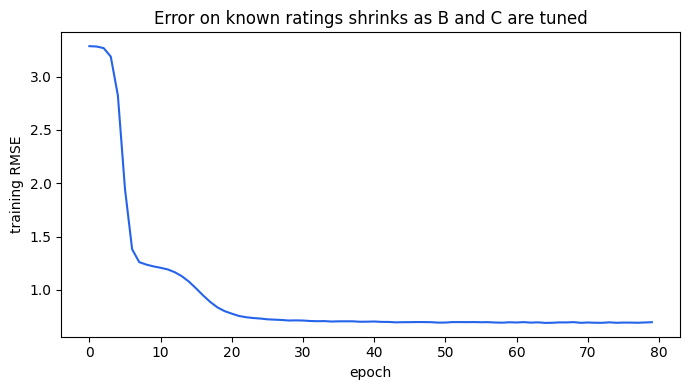

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history, color="#2563EB")
ax.set_xlabel("epoch")
ax.set_ylabel("training RMSE")
ax.set_title("Error on known ratings shrinks as B and C are tuned")
plt.tight_layout()
plt.show()

On ratings it **never saw during training**, matrix factorization is far more accurate than guessing the average.
It learned the hidden tastes just from the pattern of which users liked which items.

**Choosing `d`** — too small can't capture all the tastes; too large starts memorizing noise. Treat it like any
other hyperparameter and check test error:


In [12]:
for d in [1, 2, 3, 5, 10]:
    B_d, C_d, _ = train_mf(r_train, c_train, y_train, *full.shape, d=d)
    print(f"d = {d:>2}:  train RMSE = {rmse(B_d, C_d, r_train, c_train, y_train):.3f}   "
          f"test RMSE = {rmse(B_d, C_d, r_test, c_test, y_test):.3f}")

d =  1:  train RMSE = 1.226   test RMSE = 1.340


d =  2:  train RMSE = 0.698   test RMSE = 0.938


d =  3:  train RMSE = 0.455   test RMSE = 0.699


d =  5:  train RMSE = 0.426   test RMSE = 0.704


d = 10:  train RMSE = 0.394   test RMSE = 0.730


Training error keeps dropping as `d` grows. Test error is a different story: `d = 1` is worse than just guessing the
average (1.34 vs. 1.28) — one hidden taste is not enough. It drops sharply up to `d = 3` (0.70), then stops
improving and creeps back up at `d = 10`, even though training error is still falling. That gap between training
and test error is the familiar overfitting pattern from the
[polynomial regression](../../01-supervised-learning/02-polynomial-regression/notes.ipynb) notebook. (The data was
built from 2 hidden tastes, but `d = 3` wins here — real ratings are rounded and have extra bias, so a little
spare room helps.)

Finally, recommendations: fill every blank for one user and rank. (This user dislikes most things, so even the
top picks have modest predicted ratings — the ranking is what matters.)


In [13]:
user = 3
already_rated = set(cols[rows == user])
all_scores = B[user] @ C.T
ranked = [i for i in np.argsort(-all_scores) if i not in already_rated][:3]
print(f"User {user} has rated {len(already_rated)} of {full.shape[1]} items.")
print("Top 3 recommendations (item id, predicted rating):")
for i in ranked:
    print(f"   item {i:>2}  →  {all_scores[i]:.2f}")

User 3 has rated 12 of 30 items.
Top 3 recommendations (item id, predicted rating):
   item 20  →  2.83
   item 15  →  2.79
   item  5  →  2.75


**Related idea:** this is close to SVD / PCA — they also split a matrix into smaller pieces. The difference is
that plain SVD needs a *complete* matrix, while the training loop above only ever looks at known ratings. That
is what makes it usable on sparse recommendation data (it was central to the winning Netflix Prize solution).


## 7. Summary — revision cheat sheet

- **Recommender**: predict a score for each user–item pair, rank, show the top few. Data = a mostly-empty
  **user–item matrix** (sparse).
- **Collaborative filtering**: uses only behaviour. **User–user**: find similar users (cosine similarity), predict
  with a similarity-weighted average of their ratings. **Item–item**: same idea along items.
  Compare along the smaller, steadier side (usually items).
- **Cold start**: new user/item = empty row/column, so collaborative filtering has nothing to work with.
- **Content-based**: describe users and items with shared features, score = dot product of the two profiles.
  Works from day one, but needs hand-built features and only suggests more of the same.
- **Hybrid**: combine both — content-based for newcomers, collaborative for people with history.
- **Matrix factorization**: $A_{n \times m} \approx B_{n \times d} \cdot C_{d \times m}$ with $d \ll n, m$.
  Learn dense user/item profiles from the known ratings only (gradient descent), then fill any blank with a dot
  product. Pick `d` by test error.

**Coming next**: more recommendation topics, once I've covered them.
